In [1]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


In [3]:
diabetes_df = pd.read_csv(io.BytesIO(uploaded["diabetes.csv"]))
display(diabetes_df)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
diabetes_df.isnull().sum().sort_values(ascending = False)

Outcome                     0
Age                         0
DiabetesPedigreeFunction    0
BMI                         0
Insulin                     0
SkinThickness               0
BloodPressure               0
Glucose                     0
Pregnancies                 0
dtype: int64

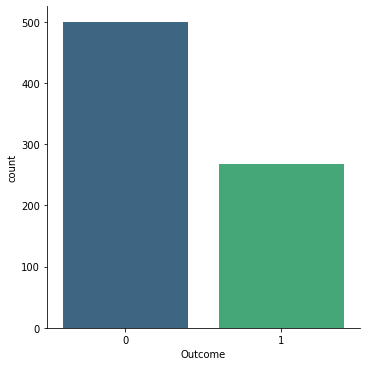

In [12]:
sns.catplot(x = 'Outcome', kind = 'count', data = diabetes_df, palette='viridis')

In [8]:
diabetes_df['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

In [9]:
from sklearn.utils import resample
df_0 = diabetes_df[diabetes_df['Outcome'] == 0]
df_1 = diabetes_df[diabetes_df['Outcome'] == 1]

In [10]:
# apply resample
df_1_over_sampling = resample(df_1 , n_samples = 500, replace = True, random_state = 123)

In [11]:
diabetes_df_balanced = pd.concat([df_0, df_1_over_sampling])

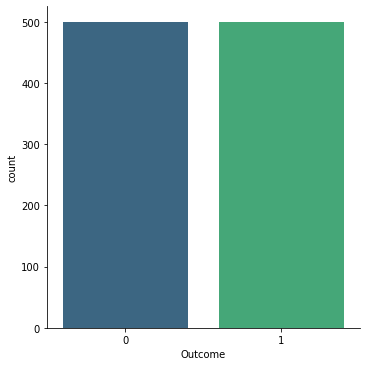

In [13]:
sns.catplot(x = 'Outcome', kind = 'count', data = diabetes_df_balanced, palette='viridis')

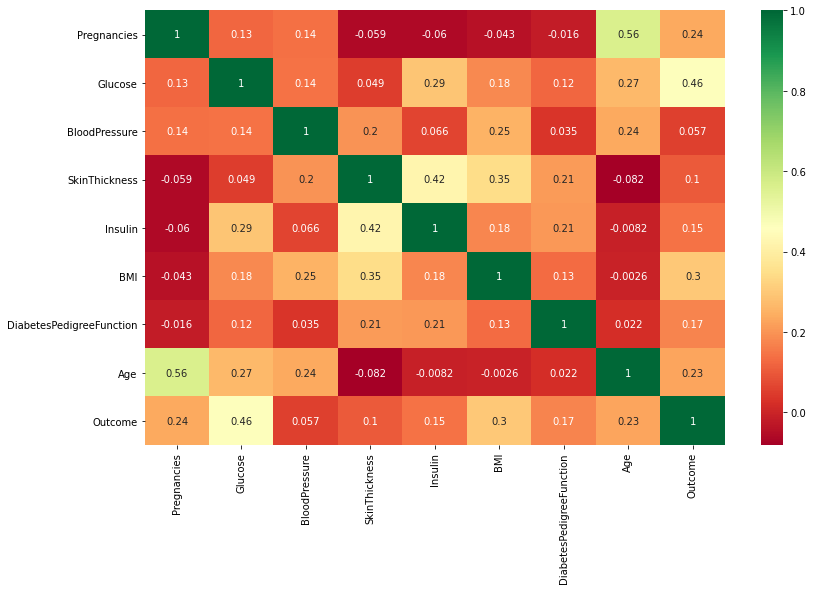

In [14]:
plt.figure(figsize=(13,8))
sns.heatmap(diabetes_df_balanced.corr(), annot= True, cmap = 'RdYlGn')

In [15]:
X = diabetes_df_balanced.drop(['Outcome'], axis = 1)
y = diabetes_df_balanced['Outcome']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 2)

In [17]:
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.optimizers import Adam

In [20]:
def build_model():
    model = Sequential()

    # Input Layer
    model.add(Dense(units = 64, activation = 'relu', input_shape = [len(X.keys())]))
    model.add(Dropout(0.2))

    # Hidden Layer - I
    model.add(Dense(units = 128, activation= 'relu'))
    model.add(Dropout(0.2))

    # Hidden Layer - II
    model.add(Dense(units = 128, activation= 'relu'))
    model.add(Dropout(0.2))

    # Output Layer
    model.add(Dense(units = 1, activation='sigmoid'))
  
    # Optimizers 
    # Learning rate 'alpha' = (0.00001 - 0.1) 
    optimizers = Adam(learning_rate= 0.001)

    # Multiclass - categorical_crossentropy
    model.compile(loss = 'binary_crossentropy', optimizer = optimizers, metrics = ['accuracy'])
    
    return model

In [21]:
model = build_model()

In [22]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                576       
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               8320      
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 128)               16512     
_________________________________________________________________
dropout_2 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 1

In [23]:
history = model.fit(X_train, y_train, epochs = 500, batch_size= 25, validation_split = 0.2)

Epoch 1/500
23/23 [==============================] - 1s 24ms/step - loss: 4.0014 - accuracy: 0.4923 - val_loss: 1.4879 - val_accuracy: 0.5500
Epoch 2/500
23/23 [==============================] - 0s 5ms/step - loss: 3.3031 - accuracy: 0.4618 - val_loss: 0.8140 - val_accuracy: 0.6571
Epoch 3/500
23/23 [==============================] - 0s 5ms/step - loss: 2.2964 - accuracy: 0.4946 - val_loss: 0.7822 - val_accuracy: 0.6143
Epoch 4/500
23/23 [==============================] - 0s 5ms/step - loss: 1.6668 - accuracy: 0.5339 - val_loss: 0.6224 - val_accuracy: 0.6714
Epoch 5/500
23/23 [==============================] - 0s 5ms/step - loss: 1.3068 - accuracy: 0.5232 - val_loss: 0.5826 - val_accuracy: 0.6643
Epoch 6/500
23/23 [==============================] - 0s 5ms/step - loss: 1.1375 - accuracy: 0.5222 - val_loss: 0.5759 - val_accuracy: 0.7000
Epoch 7/500
23/23 [==============================] - 0s 4ms/step - loss: 1.0185 - accuracy: 0.5631 - val_loss: 0.5974 - val_accuracy: 0.6714
Epoch 8/500


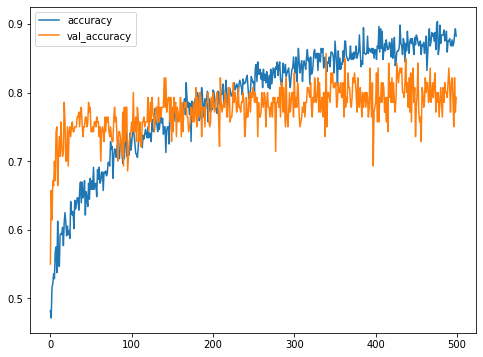

In [24]:
pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot(figsize = (8,6))

In [25]:
model.evaluate(X_test, y_test)

10/10 [==============================] - 0s 2ms/step - loss: 0.6060 - accuracy: 0.7900


[0.6059542298316956, 0.7900000214576721]

In [26]:
predict = model.predict(X_test)
yhat = np.round(predict)

In [28]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, yhat)

array([[117,  32],
       [ 31, 120]])

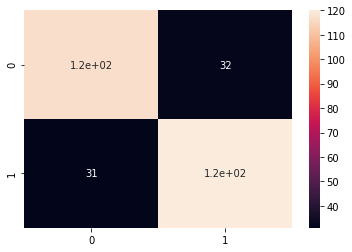

In [30]:
sns.heatmap(confusion_matrix(y_test, yhat), annot = True)